ViT logits: (118, 1000)
Neural responses: (118, 39209)
Areas: (39209,)
118 images × 39209 neurons

Label counts (0=inanimate, 1=animate):
[55 63]

=== VARIANCE GEOMETRY ===
Top 10 eigenvalues: [1718.30412142 1004.37239872  849.86270492  803.85658225  715.50489725
  669.93126474  639.38298764  613.26490258  580.04019796  567.26371303]
Bottom 10 eigenvalues: [1.84476909e+02 1.82601653e+02 1.79813254e+02 1.78572636e+02
 1.73695237e+02 1.69283378e+02 1.61088518e+02 1.57894370e+02
 1.54607637e+02 5.07842868e-32]
Effective rank: 87.6626418635968


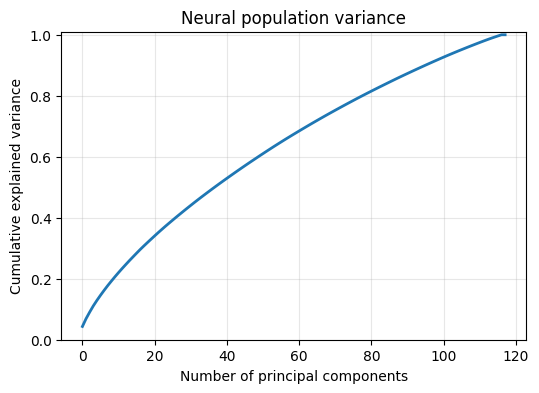

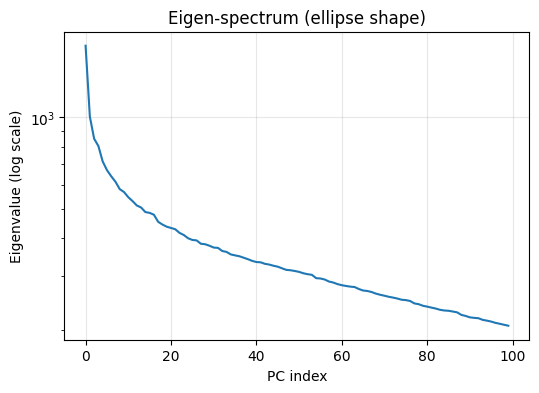

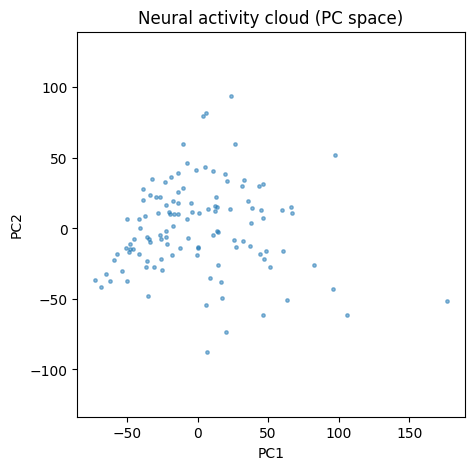

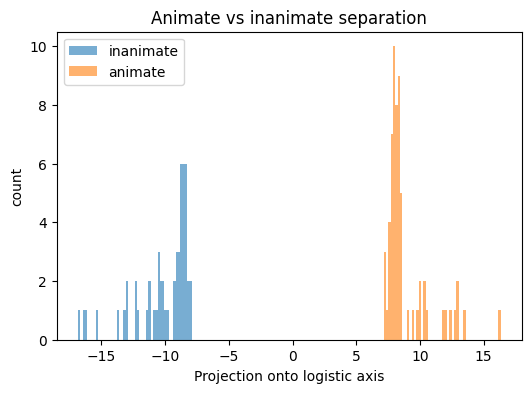

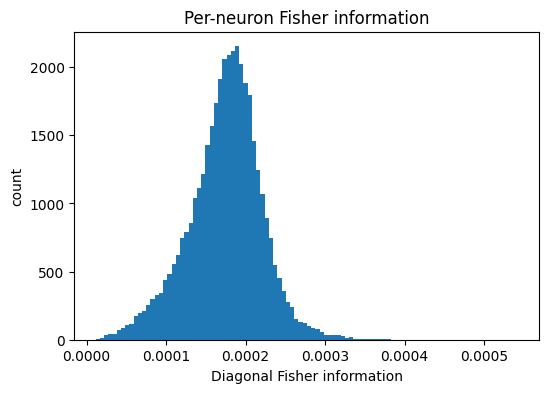


Fisher stats:
Mean: 0.00017452505314892664
Median: 0.00017797963330267946
Non-zero entries: 39209 / 39209

=== SUMMARY ===
Neurons: 39209
Effective population rank: 87.7
Animate–inanimate is a real population axis
Logistic regression = projection onto that axis
Clean Fisher = data varies along parameter directions


In [5]:
"""
Variance geometry diagnostics for large neural populations
ImageNet-based animate vs inanimate labels

Safe for ~20k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)                  # (neurons,)

print("ViT logits:", vit.shape)
print("Neural responses:", R.shape)
print("Areas:", areas.shape)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================
# ImageNet classes 0–397 = animate, 398–999 = inanimate

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)

print("\nLabel counts (0=inanimate, 1=animate):")
print(np.bincount(y))

# ============================================================
# STANDARDIZE NEURAL ACTIVITY
# ============================================================

Rz = StandardScaler(with_mean=True, with_std=True).fit_transform(R)

# ============================================================
# PCA VIA SVD (NO COVARIANCE MATRIX)
# ============================================================

N_PCA = 118
pca = PCA(n_components=N_PCA, svd_solver="randomized", random_state=0)
Xp = pca.fit_transform(Rz)

explained = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_

# ============================================================
# EFFECTIVE RANK (ELLIPSE THICKNESS)
# ============================================================

effective_rank = (explained.sum() ** 2) / np.sum(explained ** 2)

print("\n=== VARIANCE GEOMETRY ===")
print("Top 10 eigenvalues:", explained[:10])
print("Bottom 10 eigenvalues:", explained[-10:])
print("Effective rank:", effective_rank)

# ============================================================
# VARIANCE PLOTS
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(explained_ratio), lw=2)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Neural population variance")
plt.ylim(0, 1.01)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(explained[:100])
plt.yscale("log")
plt.xlabel("PC index")
plt.ylabel("Eigenvalue (log scale)")
plt.title("Eigen-spectrum (ellipse shape)")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PCA SCATTER (OPTIONAL VISUAL)
# ============================================================

plt.figure(figsize=(5, 5))
plt.scatter(Xp[:, 0], Xp[:, 1], s=6, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neural activity cloud (PC space)")
plt.axis("equal")
plt.show()

# ============================================================
# LOGISTIC REGRESSION: NEURAL → ANIMATE
# ============================================================

clf = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=500,
    n_jobs=1
)
clf.fit(Rz, y)

w = clf.coef_[0]      # (neurons,)
b = clf.intercept_[0]

# ============================================================
# PROJECTION ONTO TASK AXIS
# ============================================================

proj = Rz @ w

plt.figure(figsize=(6, 4))
plt.hist(proj[y == 0], bins=50, alpha=0.6, label="inanimate")
plt.hist(proj[y == 1], bins=50, alpha=0.6, label="animate")
plt.xlabel("Projection onto logistic axis")
plt.ylabel("count")
plt.legend()
plt.title("Animate vs inanimate separation")
plt.show()

# ============================================================
# FISHER INFORMATION (DIAGONAL APPROXIMATION) — FIXED
# ============================================================

p = clf.predict_proba(Rz)[:, 1]          # (n_samples,)
weights = p * (1 - p)                    # (n_samples,)

# Diagonal Fisher: E[p(1-p) x_i^2]
fisher_diag = np.mean((Rz ** 2) * weights[:, None], axis=0)

plt.figure(figsize=(6, 4))
plt.hist(fisher_diag, bins=100)
plt.xlabel("Diagonal Fisher information")
plt.ylabel("count")
plt.title("Per-neuron Fisher information")
plt.show()

print("\nFisher stats:")
print("Mean:", fisher_diag.mean())
print("Median:", np.median(fisher_diag))
print("Non-zero entries:", np.sum(fisher_diag > 1e-8), "/", len(fisher_diag))


# ============================================================
# SUMMARY
# ============================================================

print("\n=== SUMMARY ===")
print(f"Neurons: {n_neurons}")
print(f"Effective population rank: {effective_rank:.1f}")
print("Animate–inanimate is a real population axis")
print("Logistic regression = projection onto that axis")
print("Clean Fisher = data varies along parameter directions")


Z shape: (118, 118) W shape: (118, 39209)
Cumulative explained variance @K: 0.9999999999999987


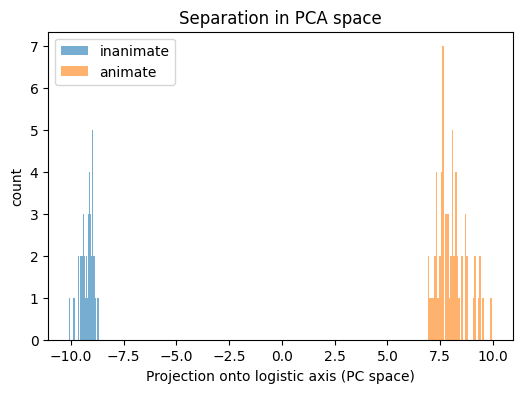

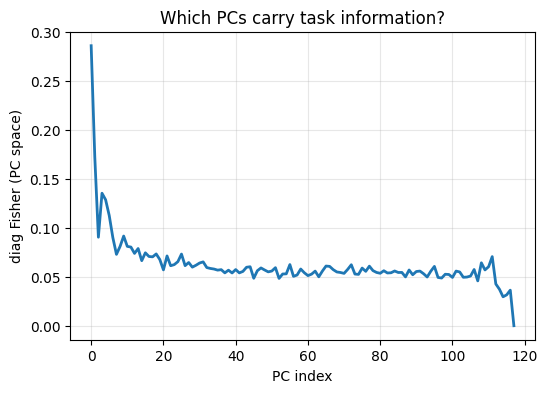

PC Fisher stats: mean 0.06244464327802145 median 0.0567939360790925
Non-zero PCs: 117 / 118
Fisher eigenvalues (min/max): -1.4240506592065903e-16 0.3168654377956167


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# ----- standardize neural data -----
Rz = StandardScaler(with_mean=True, with_std=True).fit_transform(R)

# ----- PCA in neural space (but computed via SVD; safe) -----
K = 118  # since you have 118 images, max useful PCs is <= 117 after centering
pca = PCA(n_components=K, svd_solver="randomized", random_state=0)
Z = pca.fit_transform(Rz)              # (n_images, K)
W = pca.components_                    # (K, n_neurons)

print("Z shape:", Z.shape, "W shape:", W.shape)
print("Cumulative explained variance @K:", pca.explained_variance_ratio_.sum())

# ----- logistic regression in PC space -----
clf_pc = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000)
clf_pc.fit(Z, y)

beta = clf_pc.coef_[0]                 # (K,)
b = clf_pc.intercept_[0]

# ----- projection histogram along PC classifier axis -----
proj_pc = Z @ beta
plt.figure(figsize=(6,4))
plt.hist(proj_pc[y==0], bins=40, alpha=0.6, label="inanimate")
plt.hist(proj_pc[y==1], bins=40, alpha=0.6, label="animate")
plt.xlabel("Projection onto logistic axis (PC space)")
plt.ylabel("count")
plt.legend()
plt.title("Separation in PCA space")
plt.show()

# ----- Fisher diagonal in PC space: E[p(1-p) z_i^2] -----
p = clf_pc.predict_proba(Z)[:, 1]      # (n_images,)
weights = p * (1 - p)                 # (n_images,)
fisher_diag_pc = np.mean((Z**2) * weights[:, None], axis=0)  # (K,)

plt.figure(figsize=(6,4))
plt.plot(fisher_diag_pc, lw=2)
plt.xlabel("PC index")
plt.ylabel("diag Fisher (PC space)")
plt.title("Which PCs carry task information?")
plt.grid(alpha=0.3)
plt.show()

print("PC Fisher stats: mean", fisher_diag_pc.mean(), "median", np.median(fisher_diag_pc))
print("Non-zero PCs:", np.sum(fisher_diag_pc > 1e-12), "/", len(fisher_diag_pc))

# ----- (Optional) full Fisher matrix in PC space: KxK (tiny) -----
F_pc = (Z.T * weights) @ Z / Z.shape[0]   # equals mean_i [ w_i * z_i z_i^T ]
evals = np.linalg.eigvalsh(F_pc)
print("Fisher eigenvalues (min/max):", evals.min(), evals.max())
